In [1]:
import pandas as pd

In [69]:
import mlflow
mlflow.set_tracking_uri("http://192.168.88.253:5001")


In [70]:
from mlflow.tracking import MlflowClient
import pandas as pd

client = MlflowClient()

all_data = []

# iterate over all experiments
for exp in client.search_experiments():
    # iterate over all runs in each experiment
    for run in client.search_runs([exp.experiment_id]):
        run_id = run.info.run_id

        # get all metric keys in this run
        metric_keys = run.data.metrics.keys()

        for key in metric_keys:
            # full history for each metric
            history = client.get_metric_history(run_id, key)
            for m in history:
                all_data.append({
                    "experiment_id": exp.experiment_id,
                    "experiment_name": exp.name,
                    "run_id": run_id,
                    "metric": key,
                    "step": m.step,
                    "value": m.value,
                    "timestamp": m.timestamp
                })

df = pd.DataFrame(all_data)
print(df.head())


        experiment_id  experiment_name                            run_id  \
0  776555912845021102  snake-rl-docker  0d74a42dc1d04204a880682b9a497979   
1  776555912845021102  snake-rl-docker  0d74a42dc1d04204a880682b9a497979   
2  776555912845021102  snake-rl-docker  0d74a42dc1d04204a880682b9a497979   
3  776555912845021102  snake-rl-docker  0d74a42dc1d04204a880682b9a497979   
4  776555912845021102  snake-rl-docker  0d74a42dc1d04204a880682b9a497979   

         metric  step     value      timestamp  
0  entropy_mean     1  1.087023  1760617045011  
1  entropy_mean     2  1.086202  1760617045591  
2  entropy_mean     3  1.086074  1760617045751  
3  entropy_mean     4  1.086211  1760617046228  
4  entropy_mean     5  1.086374  1760617046332  


In [71]:
df = df[(df['run_id'] == '76011aa9d17e412ab8b119030e8a0f63') |
        (df['run_id'] == '0d74a42dc1d04204a880682b9a497979')]


In [90]:
df['snakes'] = df['run_id'].apply(lambda x: "1_snake" if x=='76011aa9d17e412ab8b119030e8a0f63' else "2_snakes_no_communication")

In [189]:


#df['rolling_avg'] = df['length'].rolling(window=400, min_periods=1).mean()
#df['rolling_median'] = df['length'].rolling(window=200, min_periods=1).median()
#df2['rolling_avg'] = df2['length'].rolling(window=100, min_periods=1).mean()

Text(0, 0.5, 'length')

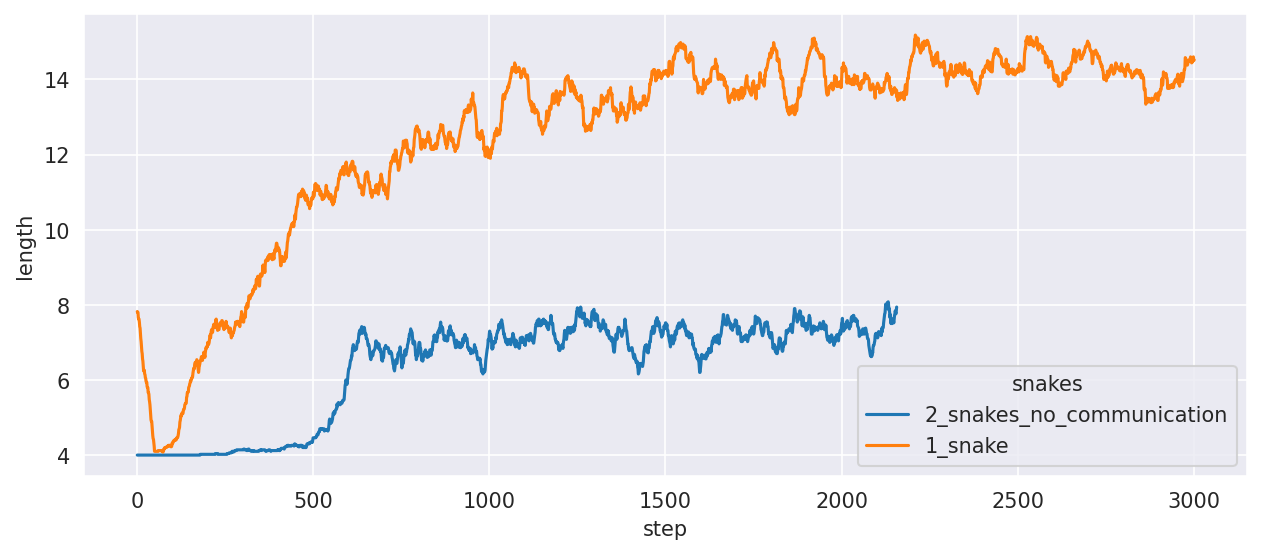

In [94]:
### import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

f,ax = plt.subplots(1,figsize=(10,4),sharex=1,dpi=150)


# sns.scatterplot(x=df.step,
#                      y=df[(df['metric']=='snake_length') | (df['metric']=='snake1_length') ]['value'],
#                      alpha = 0.2,hue=df['run_id'], s=3, ax=ax,)
sns.lineplot(x=df.step,
                      y=df[(df['metric']=='snake_length') | (df['metric']=='snake1_length')]['value'].rolling(window=50, min_periods=1).mean(),
                      ax=ax, hue=df['snakes'])
ax.set_ylabel("length")
# sns.lineplot(x=df.step,
#                      y=df[df['metric']=='loss']['value'].rolling(window=100, min_periods=1).mean(),
#                      ax=ax[1])
# ax[1].set_ylabel("loss")
# sns.lineplot(x=df.step,
#                      y=df[df['metric']=='entropy_mean']['value'].rolling(window=100, min_periods=1).mean(),
#                      ax=ax[2])
#ax[2].set_ylabel("entropy")
#sns.lineplot(x=df.index, y=df['frames'])
#sns.lineplot(x=df.index, y=df['rolling_median'])
#ax.set_xlabel("episode")

In [80]:
df[(df['metric']=='snake_length1') | (df['metric']=='snake_length1')] 

,experiment_id,experiment_name,run_id,metric,step,value,timestamp
